In [35]:
%%html
<style type="text/css">
  span.ecb { background: yellow; }
</style>
<span class="ecb">Grading comments will be in yellow</span>

In [36]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# from IPython.display import display
import itertools

# ATMO 5331 - Homework #3
### Spring 2026, Due 23 Mar, 2026, 11:59 pm.

When working these problems, you will need to code up equations for and make plots of various electrostatic quantities. Turn in a Jupyter notebook with your figures and which I can run to reproduce your results. Label your axes like a professional.

Please also enter your derivations into the notebook using $LaTeX$. Provide any needed discussion as commentary in the notebook in a Markdown cell.

Value of background electric field is 6.0 V/m
(12500,) (12500,) (12500,) <class 'numpy.ndarray'>
(39125,)
(12500,) (25, 25, 20) (12500,)
Charging 26 grid boxes
Charging 98 grid boxes
Charging 81 grid boxes
Charging 81 grid boxes


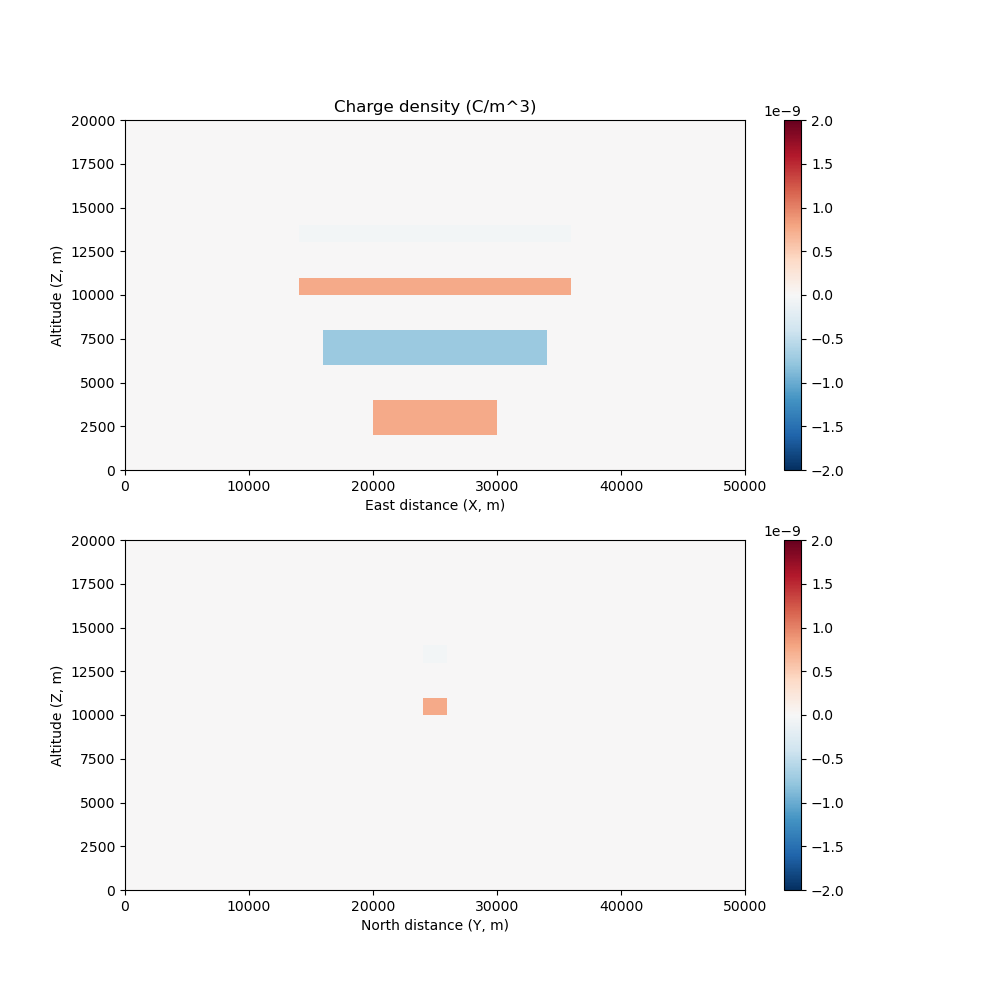

In [37]:
from fipy import Grid3D, CellVariable, DiffusionTerm
from fipy.tools.numerix import sqrtDot, reshape
import numpy as np

# Set up a 3D grid, using the engineer's coordinate convention
# x coordinate is left/right
# y coordinate is bottom/top
# z coordinate is front/back
Lx = 100.0e3/2
Ly = 100.0e3/2 # meters
Lz = 20.0e3 # approximate height of electrosphere is 65 km, Fig 1.11 MR98
dx = 2.0e3
dy = 2.0e3
dz = 1.0e3

# Horizontal coordinates of the grid center 
Xc, Yc = Lx/2.0, Ly/2.0

# Use image charges?
mirror=False

phiGround = 0. # potential of ground
phiElectrosphere = 300.0e3 # potential of electrosphere, V

print("Value of background electric field is {0} V/m".format((phiElectrosphere-phiGround)/Ly))

mesh = Grid3D(dx=dx, dy=dy, dz=dz, Lx=Lx, Ly=Ly, Lz=Lz )
X, Y, Z = mesh.cellCenters
print(X.shape, Y.shape, Z.shape, type(X))

phi = CellVariable(name = "Potential (V)",
                    mesh = mesh,
                    value = phiGround)
rho = CellVariable(name = "Charge density (C m$^{-3}$)", mesh = mesh)

# Set up the Poisson problem
permittivity = 8.854e-12 # vacuum, F/m
phi.equation = (DiffusionTerm(coeff = permittivity) + rho == 0)

# there is also grad, which is first order. facegrad is second order.
# Efield = -phi.faceGrad
# Finally, we can use leastSquaresGrad, which is calculated at the cell centers.
# This is a bit harder to imagine from the point of view of a discretized gradient calculation
# but has the advantage that we can slice the arrays the same way as the scalar variables.
Efield = -phi.leastSquaresGrad
Efield.name = 'Electric Field (V/m)'

# Only need these for faceGrad.
EfaceX, EfaceY, EfaceZ = Efield.mesh.faceCenters
print(EfaceX.shape)

# Zero E field (gradient of potential) on exterior
phi.faceGrad.constrain(0 * mesh.faceNormals, where=mesh.exteriorFaces)

# Zero potential at ground, overwrites previous condition on bottom boundary
phi.constrain(phiGround, mesh.facesFront)

# Potential provided by ionosphere, approximated as a single upper boundary, i.e., the electrosphere
phi.constrain(phiElectrosphere, mesh.facesBack)
    
print(X.shape, mesh.shape, phi.shape)

def cylinder_at(rho, rho0, X0, Y0, Z0, depth, radius):
    """ X0, Y0, Z0: Center of cylinder
    rho: whole-domain charge density variable
    rho: charge density to assign at cylinder
    depth: thickness in Z, i.e., Z0-depth/2, Z0+depth/2
    radius: cylinder radius
    """
    
    X, Y, Z = rho.mesh.cellCenters
    
    dX = X-X0
    dY = Y-Y0
    dZ = Z-Z0
    
    charged = (
        (np.sqrt(dX*dX + dY*dY) <= radius) &
        (np.abs(dZ) <= (depth/2.0))
    )
    print("Charging {0} grid boxes".format(charged.sum()))
    
    # Note the warning at https://www.ctcms.nist.gov/fipy/documentation/USAGE.html
    # Since rho does not change during the solve for phi, we can use the constraint
    # mechanism.
    # rho.constrain(rho0, charged)
    rho.setValue(rho0, where=charged)

rho0 = 0.5e-9

#cylinder_at(rho, rho0/2.0, Xc, Yc, 3.0e3, 1.2e3, 4.0e3)
cylinder_at(rho, rho0*1.5, Xc, Yc, 3.0e3, 1.2e3, 4.0e3)
cylinder_at(rho, -rho0*1.5, Xc, Yc, 7.0e3, 1.2e3, 8.0e3)
cylinder_at(rho, rho0*1.5, Xc, Yc, 10.5e3, 1.2e3, 10.0e3)   

cylinder_at(rho, -rho0/10.0, Xc, Yc, 13.5e3, 1e3, 10e3)

import matplotlib
# matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

red_blue = plt.get_cmap('RdBu_r')
helix = plt.get_cmap('cubehelix_r')

# reversed shape based on FiPy's matplotlib2DGridViewer source
mesh_shape = mesh.shape[::-1]
plotx, ploty, plotz = np.reshape(X, mesh_shape), np.reshape(Y, mesh_shape), np.reshape(Z, mesh_shape)
plotrho = np.reshape(rho.value, mesh_shape)

# Find the index along the X and Y dimensions 
# It's a cartesian grid. We have taken the min along the axis we know is repeated across
# the other two dimensions, so the value should be the same across the other two axes, 
# allowing us to select [0,0] or any other index value.
Xci = np.argmin(np.abs(plotx-(Xc+10e3)), axis=-1)[0,0]
Yci = np.argmin(np.abs(ploty-Yc), axis=-2)[0,0]

# Set up the slice location
YZslice = slice(None), slice(None), Xci
XZslice = slice(None), Yci, slice(None)

Xslice_loc = plotx[Xci, 0, 0]   # X location of NS slice
Yslice_loc = ploty[0, Yci, 0]   # Y location of EW slice

f, axs = plt.subplots(2,1,figsize=(10,10))
ax_rho_EW = axs[0]
ax_rho_NS = axs[1]

rhonorm = matplotlib.colors.Normalize(vmin=-2e-9, vmax=2e-9)

# Select center along Y to plot Z vs. X
rho_plot_EW = ax_rho_EW.pcolormesh(plotx[XZslice], plotz[XZslice], plotrho[XZslice], cmap=red_blue, norm=rhonorm)
ax_rho_EW.set_xlabel("East distance (X, m)")
ax_rho_EW.set_ylabel("Altitude (Z, m)")
ax_rho_EW.set_title("Charge density (C/m^3)")
plt.colorbar(rho_plot_EW, ax=ax_rho_EW)
rho_plot_NS = ax_rho_NS.pcolormesh(ploty[YZslice], plotz[YZslice], plotrho[YZslice], cmap=red_blue, norm=rhonorm)
ax_rho_NS.set_xlabel("North distance (Y, m)")
ax_rho_NS.set_ylabel("Altitude (Z, m)")
plt.colorbar(rho_plot_NS, ax=ax_rho_NS)

phi.equation.solve(var=phi)

# f, axs = plt.subplots(2,1,figsize=(10,10))
# ax_phi_EW = axs[0]
# ax_phi_NS = axs[1]

# phimax = 3e8

# plotphi = np.reshape(phi.value, mesh_shape)
# phinorm = matplotlib.colors.Normalize(vmin=-phimax, vmax=phimax)

# # Select center along Y to plot Z vs. X
# phi_plot_EW = ax_phi_EW.pcolormesh(plotx[XZslice], plotz[XZslice], plotphi[XZslice], cmap=red_blue, norm=phinorm)
# ax_phi_EW.set_xlabel("East distance (X, m)")
# ax_phi_EW.set_ylabel("Altitude (Z, m)")
# ax_phi_EW.set_title("Potential (V)")
# plt.colorbar(phi_plot_EW, ax=ax_phi_EW)
# phi_plot_NS = ax_phi_NS.pcolormesh(ploty[YZslice], plotz[YZslice], plotphi[YZslice], cmap=red_blue, norm=phinorm)
# ax_phi_NS.set_xlabel("North distance (Y, m)")
# ax_phi_NS.set_ylabel("Altitude (Z, m)")
# plt.colorbar(phi_plot_NS, ax=ax_phi_NS)

# f, axs = plt.subplots(2,1,figsize=(10,10))
# ax_field_EW = axs[0]
# ax_field_NS = axs[1]

# Emax = 150
# fraction = 1.0
# fieldnorm = matplotlib.colors.Normalize(vmin=0, vmax=Emax)




# # Select center along Y to plot Z vs. X
# field_plot_EW = ax_field_EW.pcolormesh(plotx[XZslice], plotz[XZslice], Emagplot[XZslice], cmap=helix, norm=fieldnorm)
# subset = ((np.random.rand(*Emagplot[XZslice].shape) < fraction) &
#           (Emagplot[XZslice] < Emax)
#          )
# field_barb_EW = ax_field_EW.barbs(plotx[XZslice][subset], plotz[XZslice][subset],
#                                   Explot[XZslice][subset], Ezplot[XZslice][subset], 
#                                   color='k', length=5)
# ax_field_EW.axvline(Xc+10e3, color = 'red', linewidth=2)
# ax_field_EW.set_xlabel("East distance (X, m)")
# ax_field_EW.set_ylabel("Altitude (Z, m)")
# ax_field_EW.set_title("Electric field (kV/m)")
# plt.colorbar(field_plot_EW, ax=ax_field_EW)

# field_plot_NS = ax_field_NS.pcolormesh(ploty[YZslice], plotz[YZslice], Emagplot[YZslice], cmap=helix, norm=fieldnorm)
# subset = ((np.random.rand(*Emagplot[YZslice].shape) < fraction) &
#           (Emagplot[YZslice] < Emax)
#          )
# field_barb_NS = ax_field_NS.barbs(ploty[YZslice][subset], plotz[YZslice][subset],
#                                   Eyplot[YZslice][subset], Ezplot[YZslice][subset], 
#                                   color='k', length=5)
# ax_field_NS.axvline(Yslice_loc, color='red', linewidth=2)
# ax_field_NS.set_xlabel("North distance (Y, m)")
# ax_field_NS.set_ylabel("Altitude (Z, m)")
# plt.colorbar(field_plot_NS, ax=ax_field_NS)


Emagplot = np.reshape(Efield.mag.value*1e-3, mesh_shape)
Explot = np.reshape(Efield[0, :].value*1e-3, mesh_shape)
Eyplot = np.reshape(Efield[1, :].value*1e-3, mesh_shape)
Ezplot = np.reshape(Efield[2, :].value*1e-3, mesh_shape)

q = np.array([15, -45, 40, -20])
z_heights = np.array([4, 7, 10, 12]) * 1000
r0 = np.zeros((4,3))
r0[:,2] = z_heights
r = np.stack([X, Y, Z], axis=-1)

E_total = np.zeros_like(r)

### 1. Comparing numeric and analytic electric field calculations

Combine your HW1 FiPy notebook with the analytic calculation functions for an infinite slab of charge and a point charge. Use the setup from HW1.1, with four charge layers, including the upper negative screening charge.

For each altitude in the FiPy grid, calculate and plot (left panel) the electric field profile from the charged cylinder in FiPy, and (right panel) the difference `({slab, point} - FiPy)` for (top row) the vertical component of the electric field and (bottom row) the total electric field magnitude.

Do this calculation at the center of the stack of charges.

For the point charges, use the same total charge as in each cylinder of charge. For the infinite slab, use the same charge density.

Mark the position of the point charges, and color-shade (with a transparent gray, `alpha=0.2`) the altitude range used for the charge slab.

Discuss the relative errors in the three approaches.

<span class="ecb">(25)</span>.

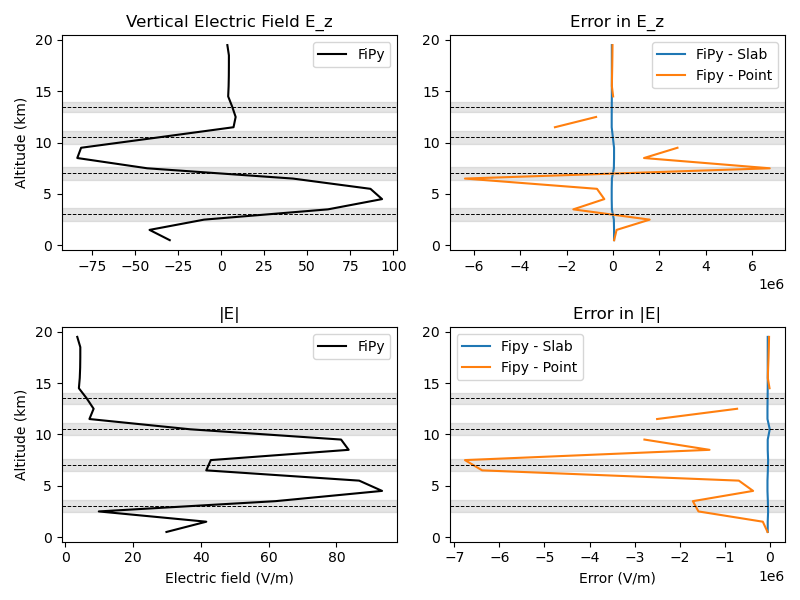

In [38]:
import numpy as np
import matplotlib.pyplot as plt

epsilon = 8.854e-12
all_z = np.arange(0, 15e3, 100.0)

#rho0 = 0.5e-9

layers = [
    dict(rho = rho0*1.5,  z0=3.0e3,  H=1.2e3, radius=4.0e3),
    dict(rho = -rho0*1.5, z0=7.0e3,  H=1.2e3, radius=8.0e3),
    dict(rho = rho0*1.5,  z0=10.5e3, H=1.2e3, radius=10.0e3),
    dict(rho = -rho0/10.0,z0=13.5e3, H=1.0e3, radius=10.0e3)
]
#Fipy E magnitude at center
ny_center = plotz.shape[1] // 2
nx_center = plotz.shape[2] // 2

z_index = plotz[:, ny_center, nx_center]
x_index = plotx[:, ny_center, nx_center]
y_index = plotz[:, ny_center, nx_center]

def slab_E(z, z0, H, rho):

    if z < z0 - H/2:
        E = -rho*H/(2*epsilon)

    elif z > z0 + H/2:
        E = rho*H/(2*epsilon)

    else:
        E = rho/epsilon * (z - z0)

    return E

def point_E(r, r0, q):
    """
    Returns the electric field at (x,y,z) = r.
    produced by a point charge q at (x0, y0, z0) = r0.
    
    Units:
    """
    r0 = np.array([0, 0, z0])
    R = r - r0
    Rmag = np.linalg.norm(R, axis=-1, keepdims=True)
    Rmag[Rmag == 0] = np.nan
    
    E = (1/(4*np.pi*epsilon)) * q * R / (Rmag**3)
    return E

#Compute E Fields 
Ez_slab = np.zeros_like(z_index)
Ez_point = np.zeros_like(z_index)

for layer in layers:

    rho_layer = layer["rho"]
    z0 = layer["z0"]
    H = layer["H"]
    R = layer["radius"]

    volume = np.pi * R**2 * H
    Q = rho_layer * volume

    for i,z in enumerate(z_index):
        Ez_slab[i] += slab_E(z, z0, H, rho_layer)
        r_point = np.array([0, 0, z]) 
        r_charge = np.array([0, 0, z0])  
        E_vec = point_E(r_point, r_charge, Q)
        Ez_point[i] += E_vec[2]



#Fipy magnitude at center
ny_center = plotz.shape[1] // 2
nx_center = plotz.shape[2] // 2

Ez_fipy = Ezplot[:,ny_center, nx_center]
Emag_fipy = Emagplot[:, ny_center, nx_center]
Emag_slab = np.abs(Ez_slab)
Emag_point = np.abs(Ez_point)


fig,axs = plt.subplots(2,2,figsize=(8,6))
ax1,ax2 = axs[0]
ax3,ax4 = axs[1]


z_index = plotz[:, ny_center, nx_center]

ax1.plot(Ez_fipy, z_index/1000, label="FiPy", color="black")
ax1.set_ylabel("Altitude (km)")
ax1.set_title("Vertical Electric Field E_z")
ax1.legend()


ax2.plot(Ez_fipy - Ez_slab, z_index/1000,label="FiPy - Slab")
ax2.plot(Ez_fipy - Ez_point, z_index/1000,label="Fipy - Point")
ax2.set_title("Error in E_z")
ax2.legend()

#E magnitude
ax3.plot(Emag_fipy, z_index/1000,label="FiPy",color="black")
ax3.set_xlabel("Electric field (V/m)")
ax3.set_ylabel("Altitude (km)")
ax3.set_title("|E|")
ax3.legend()


ax4.plot(Emag_fipy- Emag_slab, z_index/1000,label="Fipy - Slab")
ax4.plot(Emag_fipy- Emag_point, z_index/1000,label="Fipy - Point")
ax4.set_xlabel("Error (V/m)")
ax4.set_title("Error in |E|")
ax4.legend()

for layer in layers:
    z0 = layer["z0"]
    H = layer["H"]
    for ax in [ax1,ax2,ax3,ax4]:
        ax.axhline(z0/1000,color='k',linestyle='--',linewidth=0.7)
        ax.axhspan((z0-H/2)/1000,(z0+H/2)/1000,
                   color="gray",alpha=0.2)

plt.tight_layout()
plt.show()

<span class="ecb">Missing mirror charges -5</span>

### 2. The effect of charge asymmetry

When making balloon-borne measurements of the electric field, it is common to calculate the charge density using only the vertical gradient of the vertical component of the electric field (the 1-D approximation to Gauss's law). This approximation is equivalent to assuming an infinite slab of charge, with no horizontal variability in the electric field.

Repeat question 1, but for a position 5 km offset from the center of the stack of charges.

<span class="ecb">(25)</span>.

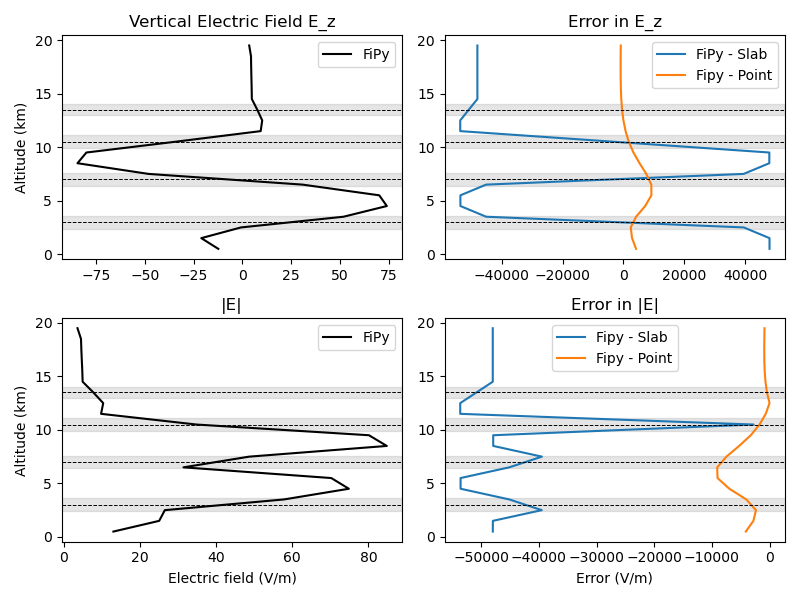

In [39]:
import numpy as np
import matplotlib.pyplot as plt

epsilon = 8.854e-12
all_z = np.arange(0, 15e3, 100.0)

#rho0 = 0.5e-9

layers = [
    dict(rho = rho0*1.5,  z0=3.0e3,  H=1.2e3, radius=4.0e3),
    dict(rho = -rho0*1.5, z0=7.0e3,  H=1.2e3, radius=8.0e3),
    dict(rho = rho0*1.5,  z0=10.5e3, H=1.2e3, radius=10.0e3),
    dict(rho = -rho0/10.0,z0=13.5e3, H=1.0e3, radius=10.0e3)
]
#Center
ny_center = plotz.shape[1] // 2
nx_center = plotz.shape[2] // 2

x_index = plotx[:, ny_center, nx_center]
y_index = plotz[:, ny_center, nx_center]


x_center = plotx[0, ny_center, nx_center]
x_target = x_center + 5000
nx_offset = np.argmin(np.abs(plotx[0, ny_center, :] - x_target))

z_index = plotz[:, ny_center, nx_offset]

def slab_E(z, z0, H, rho):

    if z < z0 - H/2:
        E = -rho*H/(2*epsilon)

    elif z > z0 + H/2:
        E = rho*H/(2*epsilon)

    else:
        E = rho/epsilon * (z - z0)

    return E

def point_E(r, r0, q):
    """
    Returns the electric field at (x,y,z) = r.
    produced by a point charge q at (x0, y0, z0) = r0.
    
    Units:
    """
    r0 = np.array([0, 0, z0])
    R = r - r0
    Rmag = np.linalg.norm(R, axis=-1, keepdims=True)
    Rmag[Rmag == 0] = np.nan
    
    E = (1/(4*np.pi*epsilon)) * q * R / (Rmag**3)
    return E

#Compute E Fields 
Ez_slab = np.zeros_like(z_index)
Ez_point = np.zeros_like(z_index)

for layer in layers:

    rho_layer = layer["rho"]
    z0 = layer["z0"]
    H = layer["H"]
    R = layer["radius"]

    volume = np.pi * R**2 * H
    Q = rho_layer * volume

    for i,z in enumerate(z_index):
        Ez_slab[i] += slab_E(z, z0, H, rho_layer)
        r_point = np.array([5000, y_index[i], z]) 
        r_charge = np.array([0, 0, z0])  
        E_vec = point_E(r_point, r_charge, Q)
        Ez_point[i] += E_vec[2] 



#Fipy E magnitude at center
ny_center = plotz.shape[1] // 2
nx_center = plotz.shape[2] // 2

Ez_fipy = Ezplot[:,ny_center, nx_offset]
Emag_fipy = Emagplot[:, ny_center, nx_offset]


#Calculate magnitude
Emag_slab = np.abs(Ez_slab)
Emag_point = np.sqrt(Ez_point**2)


fig,axs = plt.subplots(2,2,figsize=(8,6))
ax1,ax2 = axs[0]
ax3,ax4 = axs[1]

#Vertical E field
ax1.plot(Ez_fipy, z_index/1000, label="FiPy", color="black")
ax1.set_ylabel("Altitude (km)")
ax1.set_title("Vertical Electric Field E_z")
ax1.legend()


ax2.plot(Ez_fipy - Ez_slab, z_index/1000,label="FiPy - Slab")
ax2.plot(Ez_fipy - Ez_point, z_index/1000,label="Fipy - Point")
ax2.set_title("Error in E_z")
ax2.legend()

#E Magnitude
ax3.plot(Emag_fipy, z_index/1000,label="FiPy",color="black")
ax3.set_xlabel("Electric field (V/m)")
ax3.set_ylabel("Altitude (km)")
ax3.set_title("|E|")
ax3.legend()


ax4.plot(Emag_fipy- Emag_slab, z_index/1000,label="Fipy - Slab")
ax4.plot(Emag_fipy- Emag_point, z_index/1000,label="Fipy - Point")
ax4.set_xlabel("Error (V/m)")
ax4.set_title("Error in |E|")
ax4.legend()

for layer in layers:
    z0 = layer["z0"]
    H = layer["H"]
    for ax in [ax1,ax2,ax3,ax4]:
        ax.axhline(z0/1000,color='k',linestyle='--',linewidth=0.7)
        ax.axhspan((z0-H/2)/1000,(z0+H/2)/1000,
                   color="gray",alpha=0.2)

plt.tight_layout()
plt.show()

<span class="ecb">Point charge profile is too smooth - should have more variation with each charge layer. Slab differences are too large in places, e.g., above cloud and near ground should be near zero. -6.</span>

### 3. Electric field at the ground

Electric field measurements at the ground will also vary with the assumed charge structure.

Plot the vertical component of the electric field at the ground as a function of distance from the center of the stack of charges, out to the maximum distance in the FiPy grid. Plot the actual magnitude (top panel) and difference `({slab, point} - FiPy)` (bottom panel).

Discuss the relative errors in the three approaches.

<span class="ecb">(15)</span>.

Discussion: With the first approach, using the slab to approximate the E field is more appropriate since we are at the center of the stack of charges. In the first approach, there is a lot more error with the point charge than with the slab. With the second approach, using a point charge is more accurate since we are 5000 m away, and the slab is not, so the slab has more error. The magnitude of the E field is also slighty smaller in this approach since we are 5000 m away. For the third approach, I couldn't get the point charge and slab fields to plot correctly at the ground since I couldn't look at three indices (only one), but I would infer that the slab would be more accurate than the point charge at the center since the point charge would likely overestimate, so approximating with a point charge would have more error at the center. Overall, Fipy is the most accurate since it's the numerical solution, slab is more  accurate at the center, and point charge is more accurate further away. 

<span class="ecb">Calculation/indexing troubles -5</span>

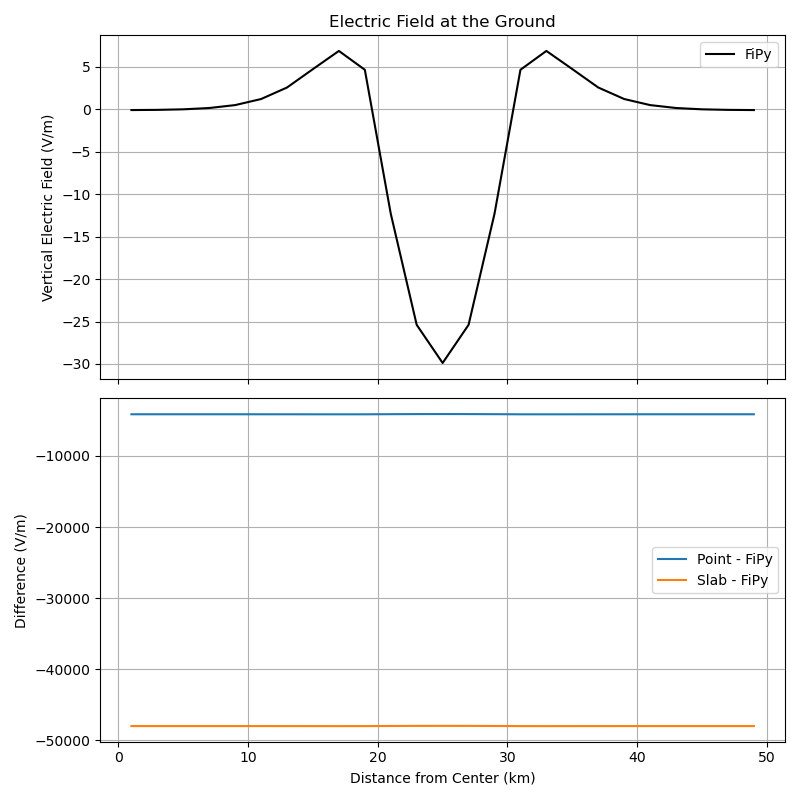

In [40]:
import numpy as np
import matplotlib.pyplot as plt

ground = plotx[0, 0, :]
Ez_fipy = Ezplot[0, Yci, :]

Ez_point_ground = np.full_like(Ez_fipy, Ez_point[0])
Ez_slab_ground  = np.full_like(Ez_fipy, Ez_slab[0]) 
diff_point = Ez_point_ground - Ez_fipy
diff_slab  = Ez_slab_ground - Ez_fipy

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,8), sharex=True)
ax1.plot(ground/1000, Ez_fipy, color = 'k', label="FiPy")
ax1.set_ylabel("Vertical Electric Field (V/m)")
ax1.set_title("Electric Field at the Ground")
ax1.legend()
ax1.grid()
ax2.plot(ground/1000, diff_point, label="Point - FiPy")
ax2.plot(ground/1000, diff_slab, label="Slab - FiPy")
ax2.set_xlabel("Distance from Center (km)")
ax2.set_ylabel("Difference (V/m)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

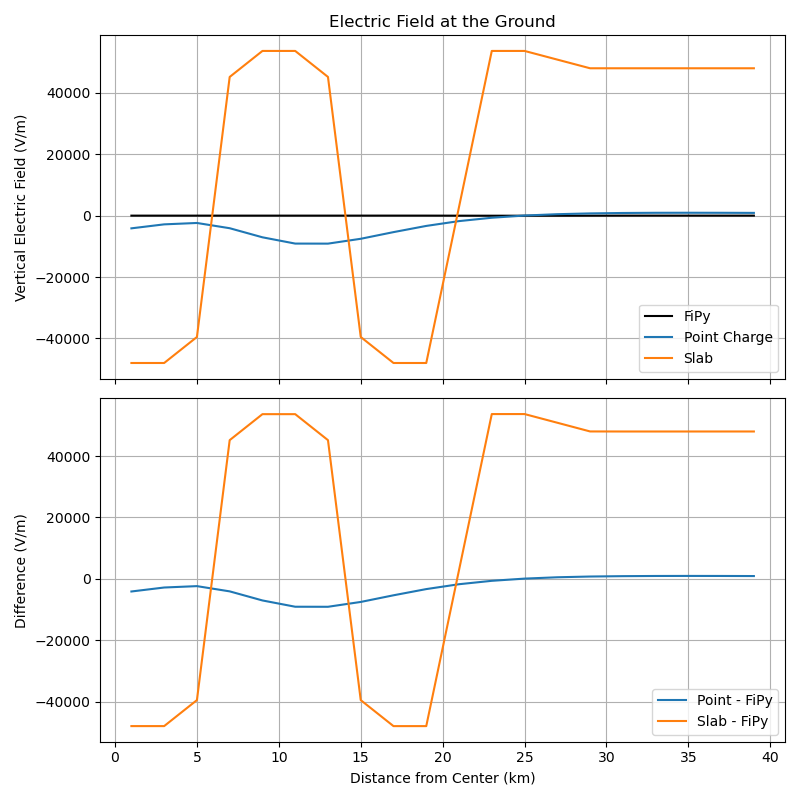

In [41]:
import numpy as np
import matplotlib.pyplot as plt

ground = plotx[0, 0, 0:20]   
Ez_fipy = Ezplot[0, Yci, 0:20]     
Ez_point_ground = Ez_point[0:20]
Ez_slab_ground  = Ez_slab[0:20]

diff_point = Ez_point_ground - Ez_fipy
diff_slab  = Ez_slab_ground - Ez_fipy

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,8), sharex=True)
ax1.plot(ground/1000, Ez_fipy, color='k', label="FiPy")
ax1.plot(ground/1000, Ez_point_ground, label="Point Charge")
ax1.plot(ground/1000, Ez_slab_ground, label="Slab")
ax1.set_ylabel("Vertical Electric Field (V/m)")
ax1.set_title("Electric Field at the Ground")
ax1.legend()
ax1.grid()
ax2.plot(ground/1000, diff_point, label="Point - FiPy")
ax2.plot(ground/1000, diff_slab, label="Slab - FiPy")
ax2.set_xlabel("Distance from Center (km)")
ax2.set_ylabel("Difference (V/m)")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()